# Clasificación automática de tipos celulares en scRNA-seq

## Contexto

En estudios de secuenciación de ARN a nivel de célula única (scRNA-seq), se obtiene información detallada sobre la expresión génica de miles de células individuales. Esto permite analizar la composición celular de un tejido**, identificar poblaciones celulares y estudiar procesos biológicos complejos como la respuesta inmunitaria o el desarrollo de enfermedades.
Cada célula tiene un perfil de expresión génica único, pero para que esta información sea interpretable, es necesario asignar cada célula a un tipo celular.

---

## Problemática

La identificación del tipo celular es un paso crítico en el análisis de datos de scRNA-seq. Sin embargo:
- Los datasets pueden contener cientos de miles de células, lo que hace inviable una clasificación manual.
- La falta de clasificación impide:
  - Determinar la composición celular del tejido
  - Identificar cambios asociados a enfermedades o tratamientos
  - Detectar subpoblaciones celulares relevantes
- Los procesos manuales son lentos, costosos y propensos a errores

En consecuencia, no identificar correctamente los tipos celulares limita la capacidad de generar conocimiento biológico y retrasa la toma de decisiones en investigación o contextos clínicos.


## Pregunta analítica

¿Es posible predecir automáticamente el tipo celular de una célula a partir de su perfil de expresión génica, con un nivel de precisión suficiente para apoyar el análisis biológico y clínico?

## Objetivos SMART

1. Desarrollar un modelo de clasificación supervisado que prediga el tipo celular a partir de la expresión génica, alcanzando un accuracy ≥ 80% y un F1-score macro ≥ 0.75 en un conjunto de prueba, mediante el uso de reducción de dimensionalidad y técnicas de manejo de desbalance, durante el desarrollo del presente análisis.
2. Evaluar el desempeño del modelo en cada tipo celular, asegurando un recall ≥ 70% en clases minoritarias, utilizando métricas como matriz de confusión y classification report, con el fin de garantizar una clasificación robusta y útil para análisis biológicos.
3. Construir un pipeline reproducible de procesamiento de datos y modelado que permita automatizar la clasificación de células en datasets de gran tamaño, documentando cada etapa (EDA, preprocesamiento y modelado) dentro del notebook para su uso en futuros análisis.

## KPIs 

- Accuracy global
- F1-score macro
- Recall en clases minoritarias
- Matriz de confusión

## Criterios de éxito

- El modelo logra diferenciar correctamente los principales tipos celulares
- Mantiene un rendimiento adecuado en clases minoritarias
- Permite interpretar la composición celular del dataset de forma automática y confiable
- Reduce la necesidad de clasificación manual en grandes volúmenes de datos

## Enfoque del análisis 
Para abordar esta problemática, se realizará:
1. Carga y comprensión del dataset (AnnData)
2. Análisis exploratorio de datos (EDA):
   - Dimensiones del dataset
   - Tipos de datos
   - Valores faltantes
   - Cardinalidad
   - Distribución de variables
3. Análisis de la matriz de expresión génica (X):
   - Tipo de matriz (sparse)
   - Densidad
4. **Exploración de representaciones de baja dimensión:**
   - PCA (componentes principales)
   - UMAP (visualización de clusters)
5. **Evaluación de calidad de datos:**
   - Duplicados
   - Correlaciones
   - Desbalance de clases
6. **Preprocesamiento inicial:**
   - Definición de lineage como variable objetivo 
   - Preparación de datos para modelado posterior
   - Estrategia de encoding (según tipo de variable)
   - Consideraciones de reducción de dimensionalidad (PCA)


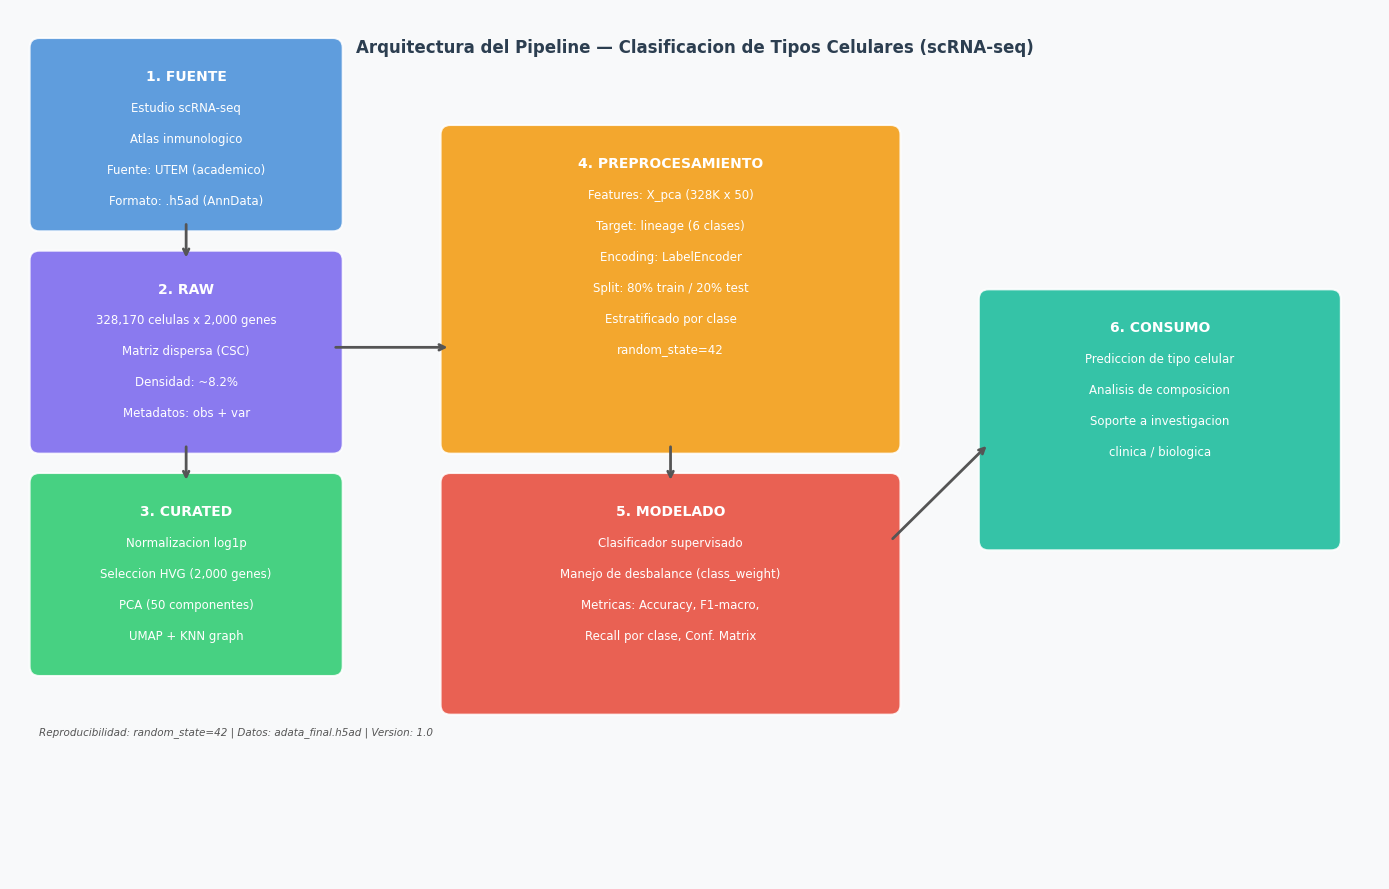

In [24]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

stage_colors = {
    'fuente':  '#4A90D9',
    'raw':     '#7B68EE',
    'curated': '#2ECC71',
    'proc':    '#F39C12',
    'modelo':  '#E74C3C',
    'consumo': '#1ABC9C',
}

def draw_box(ax, x, y, w, h, color, title, lines, fontsize=8.5):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle='round,pad=0.1',
        linewidth=1.5, edgecolor='white', facecolor=color, alpha=0.88
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.22, title,
            ha='center', va='top', fontsize=10, fontweight='bold', color='white')
    for idx, line in enumerate(lines):
        ax.text(x + w/2, y + h - 0.55 - idx*0.32, line,
                ha='center', va='top', fontsize=fontsize, color='white')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->',
                                color='#555555', lw=2.0,
                                connectionstyle='arc3,rad=0.0'))

draw_box(ax, 0.3, 6.8, 3.0, 1.8, stage_colors['fuente'], '1. FUENTE',
         ['Estudio scRNA-seq', 'Atlas inmunologico', 'Fuente: UTEM (academico)', 'Formato: .h5ad (AnnData)'])
draw_box(ax, 0.3, 4.5, 3.0, 1.9, stage_colors['raw'], '2. RAW',
         ['328,170 celulas x 2,000 genes', 'Matriz dispersa (CSC)', 'Densidad: ~8.2%', 'Metadatos: obs + var'])
draw_box(ax, 0.3, 2.2, 3.0, 1.9, stage_colors['curated'], '3. CURATED',
         ['Normalizacion log1p', 'Seleccion HVG (2,000 genes)', 'PCA (50 componentes)', 'UMAP + KNN graph'])
draw_box(ax, 4.5, 4.5, 4.5, 3.2, stage_colors['proc'], '4. PREPROCESAMIENTO',
         ['Features: X_pca (328K x 50)', 'Target: lineage (6 clases)',
          'Encoding: LabelEncoder', 'Split: 80% train / 20% test',
          'Estratificado por clase', 'random_state=42'])
draw_box(ax, 4.5, 1.8, 4.5, 2.3, stage_colors['modelo'], '5. MODELADO',
         ['Clasificador supervisado', 'Manejo de desbalance (class_weight)',
          'Metricas: Accuracy, F1-macro,', 'Recall por clase, Conf. Matrix'])
draw_box(ax, 10.0, 3.5, 3.5, 2.5, stage_colors['consumo'], '6. CONSUMO',
         ['Prediccion de tipo celular', 'Analisis de composicion',
          'Soporte a investigacion', 'clinica / biologica'])

draw_arrow(ax, 1.8, 6.8, 1.8, 6.4)
draw_arrow(ax, 1.8, 4.5, 1.8, 4.1)
draw_arrow(ax, 3.3, 5.5, 4.5, 5.5)
draw_arrow(ax, 6.75, 4.5, 6.75, 4.1)
draw_arrow(ax, 9.0, 3.5, 10.0, 4.5)

ax.text(7, 8.7,
        'Arquitectura del Pipeline — Clasificacion de Tipos Celulares (scRNA-seq)',
        ha='center', va='top', fontsize=12, fontweight='bold', color='#2c3e50')
ax.text(0.3, 1.5,
        'Reproducibilidad: random_state=42 | Datos: adata_final.h5ad | Version: 1.0',
        fontsize=7.5, color='#555555', style='italic')

plt.tight_layout()
plt.show()

**Descripción del pipeline:**

| Etapa | Descripción | Artefacto |
|---|---|---|
| 1. Fuente | Dataset original de estudio scRNA-seq | `.h5ad` (AnnData) |
| 2. Raw | Datos crudos: matriz de expresión dispersa + metadatos | `adata.X`, `adata.obs`, `adata.var` |
| 3. Curated | Preprocesamiento biológico previo: log1p, HVG, PCA, UMAP | `adata.obsm['X_pca']`, `adata.obsm['X_umap']` |
| 4. Preprocesamiento | Extracción de features, encoding, split estratificado | `X_train`, `X_test`, `y_train`, `y_test` |
| 5. Modelado | Entrenamiento y evaluación del clasificador | Modelo entrenado + métricas |
| 6. Consumo | Predicción de tipos celulares en nuevas muestras | Clasificación automática |

**Criterios de reproducibilidad:**
- `random_state=42` en todos los pasos estocásticos
- Datos fijos: `adata_final.h5ad` (no se modifica el archivo original)
- Split estratificado garantiza consistencia entre ejecuciones

In [4]:
from pathlib import Path
import anndata as ad

file_path = Path("..") / "data" / "raw" / "adata_final.h5ad"
adata = ad.read_h5ad(file_path)
print(adata)
print("Shape:", adata.shape)
print("Células (obs):", adata.n_obs)
print("Genes (vars):", adata.n_vars)


print("obs (metadatos células):", adata.obs.shape)
print("var (metadatos genes):", adata.var.shape)
print("\nobsm (embeddings):", list(adata.obsm.keys()))
print("varm (info genes):", list(adata.varm.keys()))
print("obsp (matrices entre células):", list(adata.obsp.keys()))
print("uns (configuraciones):", list(adata.uns.keys()))

AnnData object with n_obs × n_vars = 328170 × 2000
    obs: 'sample_ID', 'cluster_ID', 'cluster', 'lineage', 'sub_lineage', 'norm_group', 'lig_rec_group'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Shape: (328170, 2000)
Células (obs): 328170
Genes (vars): 2000
obs (metadatos células): (328170, 7)
var (metadatos genes): (2000, 6)

obsm (embeddings): ['X_pca', 'X_umap']
varm (info genes): ['PCs']
obsp (matrices entre células): ['connectivities', 'distances']
uns (configuraciones): ['hvg', 'log1p', 'neighbors', 'pca', 'umap']


## 1. Referencia del dataset

| Campo | Detalle |
|---|---|
| Nombre del archivo | `adata_final.h5ad` |
| Origen | Contacto académico de la Universidad Tecnológica Metropolitana (UTEM) |
| Tipo de fuente | Dataset proporcionado directamente por investigador/contacto institucional |
| Publicación / DOI | No disponible públicamente |
| Acceso | Restringido — proporcionado para uso académico en el contexto de este análisis |

**Descripción técnica del dataset:**
- Formato: AnnData (`.h5ad`)
- Células: 328,170
- Genes (highly variable): 2,000
- Variable objetivo: `lineage` (6 clases: T, MNP, B&plasma, NK, mast, pDC)
- Preprocesamiento previo documentado en el objeto AnnData: normalización log1p (`adata.uns['log1p']`), selección de HVG, PCA (50 componentes), UMAP, grafo de vecinos KNN
- Dominio: Inmunología / transcriptómica de célula única (scRNA-seq)
- Muestras de origen: 91 muestras distintas (`sample_ID`)

## Estructura del dataset

El dataset está almacenado en un objeto AnnData, una estructura especializada para datos de secuenciación de célula única (scRNA-seq). Este formato permite organizar de manera eficiente tanto la matriz de expresión génica como los metadatos asociados.

### Dimensiones del dataset
- Número de células (observaciones): 328,170  
- Número de genes (variables): 2,000  
- Shape: (328,170 × 2,000)

Esto indica que cada fila representa una célula individual, mientras que cada columna representa un gen.


### Componentes principales del AnnData

El objeto contiene múltiples estructuras que representan distintos niveles de información:
- X: matriz principal de expresión génica  
- obs: metadatos por célula (filas)  
- var: metadatos por gen (columnas)  
- obsm: representaciones de baja dimensión (PCA, UMAP)  
- varm: información asociada a genes en espacios reducidos  
- obsp: matrices entre células (distancias, vecinos)  
- uns: configuraciones y resultados del procesamiento  

Este tipo de estructura permite:
- Analizar simultáneamente expresión génica y contexto celular
- Aplicar técnicas avanzadas como reducción de dimensionalidad y clustering
- Mantener trazabilidad del procesamiento (PCA, UMAP, vecinos)

El dataset no es solo una tabla, sino un pipeline de análisis ya estructurado.

In [26]:

print("Tipo:", type(adata.X))
print("Shape:", adata.X.shape)


print("Valores no nulos (nnz):", adata.X.nnz)

densidad = adata.X.nnz / (adata.n_obs * adata.n_vars)
print("Densidad:", densidad)

print("Columnas:")
print(list(adata.var.columns))
print("\nPrimeras filas:")
print(adata.var.head())

Tipo: <class 'scipy.sparse._csc.csc_matrix'>
Shape: (328170, 2000)
Valores no nulos (nnz): 53831003
Densidad: 0.08201694700917207
Columnas:
['highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection']

Primeras filas:
          highly_variable     means  dispersions  dispersions_norm  \
HES4                 True  0.013749     0.278103          1.322268   
ISG15                True  0.231175     1.089457          4.144256   
TNFRSF18             True  0.083985     0.857051          4.510229   
TNFRSF4              True  0.097262     1.357297          7.365294   
ACOT7                True  0.050048     0.410187          2.104795   

          highly_variable_nbatches  highly_variable_intersection  
HES4                            76                         False  
ISG15                           91                          True  
TNFRSF18                        91                          True  
TNFRSF4                       

##  Matriz de expresión génica

La matriz X contiene los valores de expresión génica para cada célula.

- Tipo: matriz dispersa (csc_matrix)
- Dimensión: (328,170 × 2,000)
- Valores no nulos: 53,831,003
- Densidad: ~8.2%

La matriz es dispersa, lo que significa que la mayoría de los valores son cero. Solo el 8.2% de las combinaciones célula-gen tienen expresión detectable.

Esto es esperado en scRNA-seq, ya que no todos los genes se expresan en todas las células y existen muchos ceros biológicos o técnicos 

###  Implicaciones para el análisis

- No se debe convertir a matriz densa por consumo extremo de memoria
- Se deben usar métodos optimizados para datos dispersos
- Justifica el uso de técnicas como PCA para reducir dimensionalidad

## Metadatos de genes (var)

El objeto var contiene información asociada a cada gen del dataset.

### Variables disponibles

- highly_variable: indica si el gen es altamente variable  
- means: promedio de expresión del gen  
- dispersions: variabilidad de expresión  
- dispersions_norm: dispersión normalizada  
- highly_variable_nbatches: número de batches donde es variable  
- highly_variable_intersection: intersección entre batches  


Los genes marcados como highly_variable son los más informativos y la dispersión permite identificar genes con alta variabilidad entre células
Estos genes suelen ser los más relevantes para:
  - Clasificación celular
  - Clustering
  - Reducción de dimensionalidad

No todos los genes aportan información útil. El dataset ya incluye una selección de genes relevantes, lo cual mejora la eficiencia computacional y calidad del análisis. Esto indica que el dataset ya pasó por un preprocesamiento biológico importante.

In [27]:
print("Disponibles:", list(adata.obsm.keys()))
print("\nShape PCA:", adata.obsm["X_pca"].shape)
print("Primeras filas PCA:")
print(adata.obsm["X_pca"][:5])


Disponibles: ['X_pca', 'X_umap']

Shape PCA: (328170, 50)
Primeras filas PCA:
[[-4.09735775e+00 -1.18622303e+00  3.25453252e-01  3.05256677e+00
   3.09687638e+00 -2.31037331e+00 -8.39496672e-01 -1.62999499e+00
  -2.14188948e-01 -1.24669230e+00 -5.55537343e-01 -1.40527940e+00
  -3.13373953e-01  1.12818396e+00 -1.16901827e+00 -6.84293434e-02
   6.12139523e-01 -3.65352243e-01  6.83010459e-01  4.54381667e-03
  -1.05327320e+00 -1.66748810e+00  9.08794105e-01  5.54386437e-01
  -1.08608806e+00 -1.14967600e-01  7.36814216e-02 -7.64655650e-01
  -4.55647796e-01  1.21648312e-01  4.93375026e-02  1.21912844e-01
   4.98525351e-01 -2.80199260e-01  6.03086948e-01  1.11443162e-01
   3.84400278e-01  1.02065790e+00 -2.96732903e-01 -3.49560678e-01
   5.17813601e-02 -8.58999014e-01  4.12348300e-01  4.07978654e-01
   7.09267378e-01  1.96136355e-01 -2.65394062e-01  8.89793336e-01
  -3.75087440e-01 -2.15469133e-02]
 [-3.39039516e+00 -8.85422885e-01  6.09708846e-01  2.93795180e+00
   2.82092619e+00 -2.05414891

## PCA (Análisis de Componentes Principales)
El dataset incluye una representación reducida mediante PCA. Y tiene caracteristicas como:
- Shape: (328,170 × 50)
- Cada célula está representada por 50 componentes principales

El PCA reduce las 2000 variables (genes) a 50 componentes y cada componente es una combinación de genes que captura variabilidad. Lo que permite:
- Reducir ruido
- Eliminar redundancia
- Facilitar el entrenamiento de modelos

Los primeros componentes capturan la mayor variabilidad biológica y las coordenadas PCA no tienen interpretación directa, pero sí resumen patrones. Este dataset ya incluye PCA, lo que indica que está listo para análisis avanzados.

In [28]:
print("\nShape UMAP:", adata.obsm["X_umap"].shape)
print("Primeras filas UMAP:")
print(adata.obsm["X_umap"][:5])


Shape UMAP: (328170, 2)
Primeras filas UMAP:
[[-4.037587   3.2977126]
 [-4.21911    3.2607813]
 [-4.337981   2.6735783]
 [-2.6851587  3.903112 ]
 [13.909807   3.9074752]]


## UMAP (Uniform Manifold Approximation and Projection)

UMAP es una técnica de reducción de dimensionalidad utilizada principalmente para visualización. Nos deja:
- Shape: (328,170 × 2)
- Cada célula tiene coordenadas en un plano 2D

Cada punto representa una célula y la posición refleja la similitud en expresión génica:
  - Células cercanas → perfiles similares
  - Células lejanas → perfiles distintos

UMAP permite visualizar clusters celulares.

Facilita identificar:
  - Tipos celulares
  - Subpoblaciones
  - Transiciones biológicas

In [29]:
print("connectivities shape:", adata.obsp["connectivities"].shape)
print("distances shape:", adata.obsp["distances"].shape)

connectivities shape: (328170, 328170)
distances shape: (328170, 328170)


## Grafo de vecinos entre células

El dataset incluye matrices que representan relaciones entre células. Con caracteristicas como:
- connectivities:(328,170 × 328,170)
- distances: (328,170 × 328,170)

Estas matrices representan un grafo de vecinos donde cada célula está conectada con otras similares

Tipos:
- connectivities: fuerza de conexión entre células  
- distances: distancia entre células en el espacio PCA  

Esto permite:
- Construir clusters
- Analizar relaciones entre células
- Detectar estructuras biológicas complejas

Estas matrices también son dispersas, por lo tanto no deben manipularse como matrices completas en memoria

In [30]:
print("DIMENSIONES")
print("Células:", adata.n_obs)
print("Genes:", adata.n_vars)
print("Shape:", adata.shape)

print("\nTipo de matriz X:")
print(type(adata.X))

nnz = adata.X.nnz
total = adata.n_obs * adata.n_vars
densidad = nnz / total

print("\nValores no nulos:", nnz)
print("Densidad:", densidad)

DIMENSIONES
Células: 328170
Genes: 2000
Shape: (328170, 2000)

Tipo de matriz X:
<class 'scipy.sparse._csc.csc_matrix'>

Valores no nulos: 53831003
Densidad: 0.08201694700917207


## Dimensiones y estructura del dataset

El dataset analizado contiene:
- 328.170 células (observaciones)
- 2.000 genes (variables)
- Dimensión total: (328170 × 2000)
- Valores no nulos: 53.831.003
- Densidad: 0.082 (≈ 8.2%)

El dataset es altamente dimensional, lo cual es típico en scRNA-seq. Esto tiene implicancias importantes como:
- No es eficiente trabajar directamente con los 2000 genes
- Es necesario usar reducción de dimensionalidad (PCA) para modelado
- Algunos modelos deben adaptarse a datos dispersos

In [31]:
print("TIPOS DE DATOS (obs)")
print(adata.obs.dtypes)

print("\nTIPOS DE DATOS (var)")
print(adata.var.dtypes)

TIPOS DE DATOS (obs)
sample_ID        category
cluster_ID          int64
cluster             int64
lineage          category
sub_lineage      category
norm_group       category
lig_rec_group    category
dtype: object

TIPOS DE DATOS (var)
highly_variable                    bool
means                           float64
dispersions                     float64
dispersions_norm                float32
highly_variable_nbatches          int64
highly_variable_intersection       bool
dtype: object


## Tipos de datos
### Variables en obs (células)
- Categóricas:
    - sample_ID
    - lineage
    - sub_lineage
    - norm_group
    - lig_rec_group
- Numéricas:
    - cluster_ID
    - cluster
### Variables en var (genes)
- Booleanas:
    - highly_variable
    - highly_variable_intersection
- Numéricas:
    - means
    - dispersions
    - dispersions_norm
    - highly_variable_nbatches

La variable objetivo lineage es categórica nominal porque no tiene orden por lo tanto requiere One Hot Encoding. Además, el foco estará en transformación para modelado, no limpieza básica

In [32]:
print("VALORES NULOS (obs)")
print(adata.obs.isnull().sum())

print("\nVALORES NULOS (var)")
print(adata.var.isnull().sum())

VALORES NULOS (obs)
sample_ID        0
cluster_ID       0
cluster          0
lineage          0
sub_lineage      0
norm_group       0
lig_rec_group    0
dtype: int64

VALORES NULOS (var)
highly_variable                 0
means                           0
dispersions                     0
dispersions_norm                0
highly_variable_nbatches        0
highly_variable_intersection    0
dtype: int64


## Valores faltantes

No se detectaron valores nulos en ninguna variable:
- obs: 0 valores faltantes
- var: 0 valores faltantes

El dataset es completo y no se requiere imputación de datos, esto permite avanzar directamente a análisis y modelado

In [33]:
print("CARDINALIDAD")

for col in adata.obs.columns:
    print(f"{col}: {adata.obs[col].nunique()} valores únicos")

print("\nGENES ")
print("Número total de genes:", adata.n_vars)
print("Número de genes altamente variables:", adata.var['highly_variable'].sum())

CARDINALIDAD
sample_ID: 91 valores únicos
cluster_ID: 49 valores únicos
cluster: 49 valores únicos
lineage: 6 valores únicos
sub_lineage: 30 valores únicos
norm_group: 5 valores únicos
lig_rec_group: 10 valores únicos

GENES 
Número total de genes: 2000
Número de genes altamente variables: 2000


## Cardinalidad
- Variables de células (obs)
    - sample_ID: 91 valores
    - cluster_ID: 49 valores
    - cluster: 49 valores
    - lineage: 6 clases
    - sub_lineage: 30 clases
    - norm_group: 5 clases
    - lig_rec_group: 10 clases
- Genes
    - Total genes: 2000
    - Genes altamente variables: 2000

lineage tiene 6 clases → problema de clasificación multiclase, entonces puede haber desbalance de clases y dificultad en clases minoritarias.

- Todos los genes fueron seleccionados como altamente variables
- Reduce ruido
- Mejora calidad del análisis

In [34]:
print(" DESCRIPCIÓN DE VAR ")
adata.var.describe()

 DESCRIPCIÓN DE VAR 


,means,dispersions,dispersions_norm,highly_variable_nbatches
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.127823,0.397357,1.295272,55.446500
std,0.292704,0.570945,1.635759,20.995179
min,0.000519,0.052611,0.030257,26.000000
25%,0.016103,0.128189,0.377960,36.000000
50%,0.047776,0.192921,0.694472,52.000000
75%,0.128532,0.408716,1.453981,75.000000
max,4.694756,6.281118,14.356705,91.000000


## Estadísticos descriptivos

- means (expresión promedio):
    - Distribución sesgada → muchos genes con baja expresión
    - Pocos genes con expresión alta (outliers biológicos)
- dispersions (variabilidad):
    - Alta dispersión indica genes con comportamiento variable entre células
    - Clave para diferenciar tipos celulares
- dispersions_norm:
    - Normalización de la variabilidad → permite comparar genes

Alta variabilidad genética → dataset informativo, por lo tanto se justifica el uso de:
- PCA
- clustering
- modelos de clasificación

También se ve la presencia de valores extremos que pueden afectar modelos sensibles a escala.

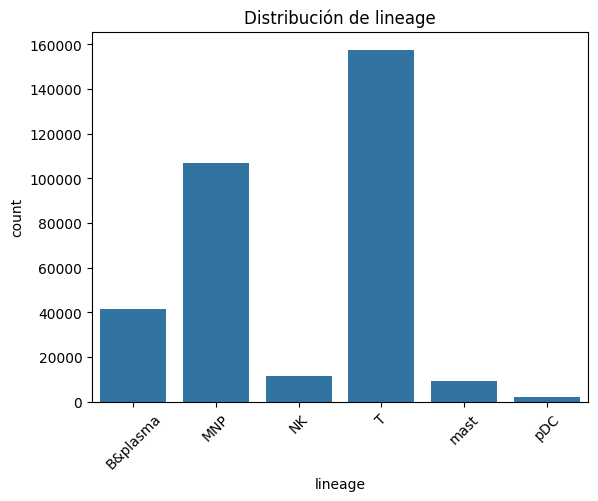

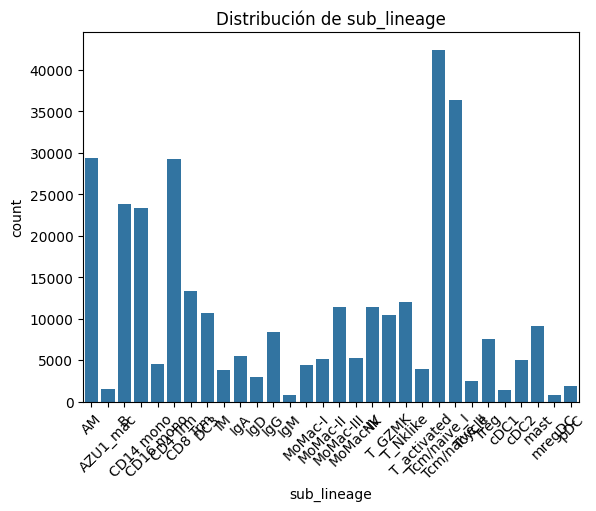

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(data=adata.obs, x="lineage")
plt.xticks(rotation=45)
plt.title("Distribución de lineage")
plt.show()

plt.figure()
sns.countplot(data=adata.obs, x="sub_lineage")
plt.xticks(rotation=45)
plt.title("Distribución de sub_lineage")
plt.show()

## Distribución de la variable objetivo
| lineage | count | proportion |
|----------|----------|----------|
| T    | 157641   | 0.480   |
| MNP    | 106662  | 0.325   |
| B&plasma    | 41422   | 0.126  |
| NK   | 11456   | 0.035   |
| mast    | 9082   | 0.028   |
| pDC    | 1907  | 0.006  |

La distribución de lineage muestra un fuerte desbalance de clases:
- La clase T representa casi la mitad del dataset (~48%) y MNP también es dominante (~32%)
- Las clases minoritarias como NK, mast, pDC tienen una representación muy baja

El modelo puede sesgarse hacia las clases mayoritarias, Puede tener alta accuracy pero bajo desempeño en clases minoritarias

### Distribución de subtipos celulares
| sub_lineage  | count | proportion |
| ------------ | ----- | ---------- |
| Tcm/naive_I  | 42434 | 0.129      |
| Tcm/naive_II | 36372 | 0.111      |
| AM           | 29324 | 0.089      |
| CD4 Trm      | 29264 | 0.089      |
| B            | 23812 | 0.073      |
| CD14 mono    | 23380 | 0.071      |
| CD8 Trm      | 13331 | 0.041      |
| T_Nklike     | 11956 | 0.036      |
| NK           | 11456 | 0.035      |
| MoMac-III    | 11428 | 0.035      |

Existen 30 subtipos celulares, lo que indica una alta granularidad biológica. La distribución también es desbalanceada.
Algunos subtipos concentran gran cantidad de células, mientras que otros son muy poco frecuentes.


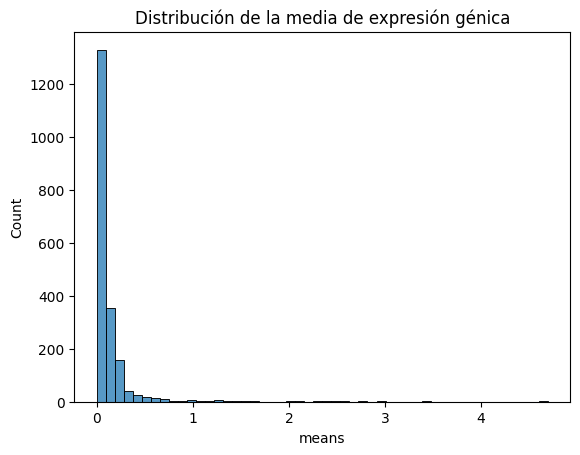

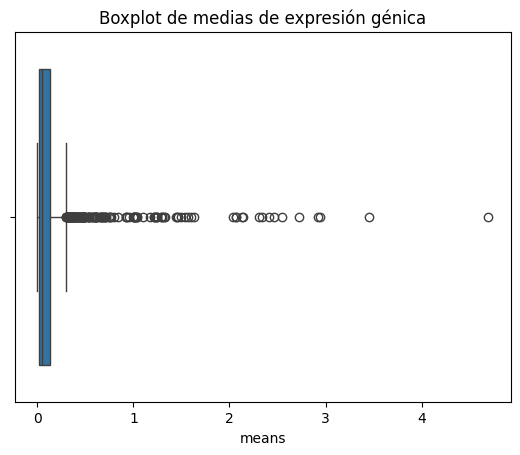

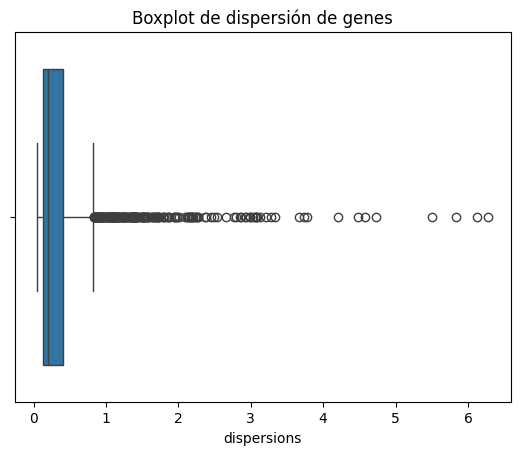

In [36]:
plt.figure()
sns.histplot(adata.var["means"], bins=50)
plt.title("Distribución de la media de expresión génica")
plt.show()

plt.figure()
sns.boxplot(x=adata.var["means"])
plt.title("Boxplot de medias de expresión génica")
plt.show()

plt.figure()
sns.boxplot(x=adata.var["dispersions"])
plt.title("Boxplot de dispersión de genes")
plt.show()

## Distribución de la media de expresión génica
Este gráfico muestra cómo se distribuye la expresión promedio de los genes.

Se puede ver que la mayoría de los genes tienen valores muy cercanos a cero, lo que significa que casi no se expresan (es decir, no están activos y no están siendo utilizados por la célula) en la mayoría de las células.

A medida que los valores de expresión aumentan, hay cada vez menos genes con esos valores altos.

En resumen, la mayoría de los genes se expresan poco, y solo unos pocos genes tienen una expresión alta.

### Implicancias
- La mayoría de los genes aportan poca información para la clasificación
- Existen pocos genes altamente expresados que son más informativos
- Justifica el uso de técnicas de:
  - reducción de dimensionalidad (PCA)
  - selección de genes relevantes

## Boxplot de la media de expresión génica 

El boxplot de la media de expresión génica permite observar la distribución, mediana y presencia de valores atípicos (outliers). Se observa que la caja está concentrada cerca de cero, lo que indica que la mediana y el rango intercuartílico son bajos.

Además, se identifican outliers que alcanzan valores cercanos a 4.5, lo que evidencia la existencia de genes con niveles de expresión significativamente más altos que el resto.

La distribución es altamente asimétrica, con una gran concentración de genes de baja expresión y unos pocos genes con alta expresión.

Esto implica: 
- Presencia de outliers biológicos (esperados en scRNA-seq)
- Estos genes pueden ser clave para diferenciar tipos celulares
- El modelo debe ser robusto frente a valores extremos
- Se justifica el uso de escalamiento o reducción de dimensionalidad

## Boxplot de la dispersión génica
El boxplot de la dispersión de genes muestra la variabilidad de la expresión génica entre células. Se observa que la mayoría de los genes presentan baja dispersión, concentrándose cerca de cero.

Sin embargo, existen varios outliers que alcanzan valores cercanos a 6, indicando la presencia de genes con alta variabilidad en su expresión.

Los genes con mayor dispersión son aquellos que varían más entre células, lo que los hace especialmente relevantes para distinguir entre tipos celulares.

Lo que implica:
- Los genes con alta dispersión son los más informativos para el modelo
- Estos genes suelen ser seleccionados como highly variable genes


Tipo de X: <class 'scipy.sparse._csc.csc_matrix'>
¿Es matriz dispersa?: True
Media global: 1.0489907
Desviación estándar: 0.68231434
Valor mínimo: 0.6931472
Valor máximo: 7.4295206


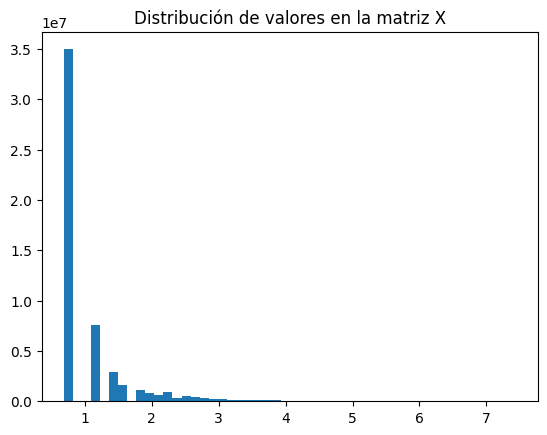

Promedio por célula:
Media: 0.086035
Min: 0.008301136
Max: 0.18439206

Promedio por gen:
Media: 0.08601852
Min: 0.0002796467
Max: 4.308375


In [37]:
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt
print("Tipo de X:", type(adata.X))
print("¿Es matriz dispersa?:", issparse(adata.X))


X = adata.X

# Convertir a array si es sparse
if issparse(X):
    X_data = X.data
else:
    X_data = X.flatten()

print("Media global:", np.mean(X_data))
print("Desviación estándar:", np.std(X_data))
print("Valor mínimo:", np.min(X_data))
print("Valor máximo:", np.max(X_data))


X = adata.X

if issparse(X):
    data = X.data
else:
    data = X.flatten()

plt.figure()
plt.hist(data, bins=50)
plt.title("Distribución de valores en la matriz X")
plt.show()

mean_per_cell = np.array(adata.X.mean(axis=1)).flatten()

print("Promedio por célula:")
print("Media:", mean_per_cell.mean())
print("Min:", mean_per_cell.min())
print("Max:", mean_per_cell.max())

mean_per_gene = np.array(adata.X.mean(axis=0)).flatten()


print("\nPromedio por gen:")
print("Media:", mean_per_gene.mean())
print("Min:", mean_per_gene.min())
print("Max:", mean_per_gene.max())

## Análisis de la matriz X
La matriz principal del dataset corresponde a una matriz de expresión génica de tipo:
- Tipo: scipy.sparse.csc_matrix
- Es una matriz dispersa

Esto significa que la mayoría de sus valores son ceros, lo cual es característico en datos de scRNA-seq. La mayoría de los genes no se expresan en la mayoría de las células. Además, el dataset es altamente eficiente en memoria gracias a esta representación

Se obtuvieron las siguientes estadísticas globales:
- Media: 1.0489  
- Desviación estándar: 0.6823  
- Valor mínimo: 0.6931  
- Valor máximo: 7.4295  

Además, el histograma muestra que:
- La mayoría de los valores están concentrados en valores bajos
- A medida que los valores aumentan, la frecuencia disminuye considerablemente

La mayoría de las expresiones génicas son bajas y existen pocos valores altos (genes altamente expresados). Por lo tanto, la distribución está sesgada hacia valores pequeños.

Esto es completamente normal en datos biológicos de scRNA-seq.

### Promedio de expresión por célula
- Media: 0.086  
- Mínimo: 0.008  
- Máximo: 0.184

Esto indica que:
- Cada célula expresa una cantidad relativamente baja de genes en promedio
- Existe variabilidad entre células, pero en rangos pequeños

Esto sugiere heterogeneidad celular, lo cual es esperado en este tipo de datos.

### Promedio de expresión por gen
- Media: 0.086  
- Mínimo: 0.00027  
- Máximo: 4.308  

Nos muestra:
- La mayoría de los genes tienen expresión muy baja
- Solo unos pocos genes presentan alta expresión

Esto refuerza la idea de que existen genes más relevantes para diferenciar tipos celulares.



In [38]:
print("Shape PCA:", adata.obsm["X_pca"].shape)
print("Primeras filas PCA:")
print(adata.obsm["X_pca"][:5])

Shape PCA: (328170, 50)
Primeras filas PCA:
[[-4.09735775e+00 -1.18622303e+00  3.25453252e-01  3.05256677e+00
   3.09687638e+00 -2.31037331e+00 -8.39496672e-01 -1.62999499e+00
  -2.14188948e-01 -1.24669230e+00 -5.55537343e-01 -1.40527940e+00
  -3.13373953e-01  1.12818396e+00 -1.16901827e+00 -6.84293434e-02
   6.12139523e-01 -3.65352243e-01  6.83010459e-01  4.54381667e-03
  -1.05327320e+00 -1.66748810e+00  9.08794105e-01  5.54386437e-01
  -1.08608806e+00 -1.14967600e-01  7.36814216e-02 -7.64655650e-01
  -4.55647796e-01  1.21648312e-01  4.93375026e-02  1.21912844e-01
   4.98525351e-01 -2.80199260e-01  6.03086948e-01  1.11443162e-01
   3.84400278e-01  1.02065790e+00 -2.96732903e-01 -3.49560678e-01
   5.17813601e-02 -8.58999014e-01  4.12348300e-01  4.07978654e-01
   7.09267378e-01  1.96136355e-01 -2.65394062e-01  8.89793336e-01
  -3.75087440e-01 -2.15469133e-02]
 [-3.39039516e+00 -8.85422885e-01  6.09708846e-01  2.93795180e+00
   2.82092619e+00 -2.05414891e+00 -8.71209502e-01 -1.58472192e+

Se aplicó PCA (Análisis de Componentes Principales) para reducir la dimensionalidad del dataset, pasando de 2000 genes a 50 componentes principales.

El resultado obtenido fue shape (328170, 50)

Esto significa que:
- Cada una de las 328170 células ahora está representada por 50 variables en lugar de 2000
- Cada componente principal es una combinación de múltiples genes

Esto permite reducir la complejidad del dataset manteniendo la mayor cantidad posible de información relevante.

Los valores de PCA representan nuevas variables construidas a partir de combinaciones lineales de los genes originales.

Esto implica que:
- Cada componente principal resume patrones de expresión génica
- Los primeros componentes capturan las estructuras más importantes del dataset
- Los últimos componentes contienen información menos relevante o ruido

Por lo tanto, PCA permite transformar los datos a un espacio más compacto y útil para análisis posteriores.

In [39]:
print("Varianza explicada por componente:")
print(adata.uns["pca"]["variance_ratio"])

var_ratio = adata.uns["pca"]["variance_ratio"]
var_acumulada = np.cumsum(var_ratio)

print("\nVarianza acumulada:")
print(var_acumulada)

Varianza explicada por componente:
[0.17356881 0.04518358 0.03349506 0.0251829  0.02201328 0.01746702
 0.01609971 0.01187737 0.00868854 0.00768747 0.00715127 0.00676576
 0.0060937  0.00568257 0.00530781 0.00508376 0.00490006 0.00459369
 0.00430519 0.00415368 0.00389744 0.0037645  0.00364839 0.0035251
 0.00323688 0.00315421 0.00306131 0.00294574 0.00278669 0.00274407
 0.00264117 0.00255076 0.00243163 0.00239745 0.00237943 0.002306
 0.00228663 0.00223959 0.00219977 0.00216381 0.00212064 0.00209715
 0.00203325 0.00201213 0.00197112 0.00194136 0.00191525 0.00190932
 0.00186967 0.00184678]

Varianza acumulada:
[0.17356881 0.2187524  0.25224745 0.27743036 0.29944363 0.31691065
 0.33301038 0.34488776 0.3535763  0.36126378 0.36841506 0.3751808
 0.38127452 0.38695708 0.3922649  0.39734867 0.40224874 0.4068424
 0.4111476  0.41530126 0.4191987  0.4229632  0.4266116  0.4301367
 0.4333736  0.43652782 0.4395891  0.44253486 0.44532156 0.44806564
 0.4507068  0.45325756 0.4556892  0.45808664 0.46046606

### La varianza

La varianza explicada por los componentes muestra cuánta información del dataset original captura cada uno.

Resultados observados:
- El primer componente explica aproximadamente 17.3% de la varianza
- Los siguientes componentes explican cada vez menos varianza
- Existe una caída rápida en la varianza explicada en los primeros componentes

Esto indica que gran parte de la información del dataset se concentra en los primeros componentes.

### La varianza acumulada

La varianza acumulada indica cuánta información total se ha capturado al sumar componentes.

Con 50 componentes se alcanza aproximadamente un 49% de la varianza total

Esto significa que:
- Se ha reducido significativamente la dimensionalidad
- Pero también se ha perdido parte de la información original

Sin embargo, este comportamiento es común en datasets de scRNA-seq debido a su alta complejidad y ruido biológico.

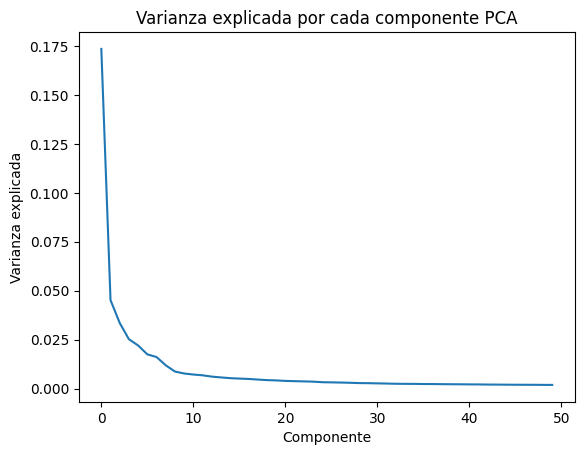

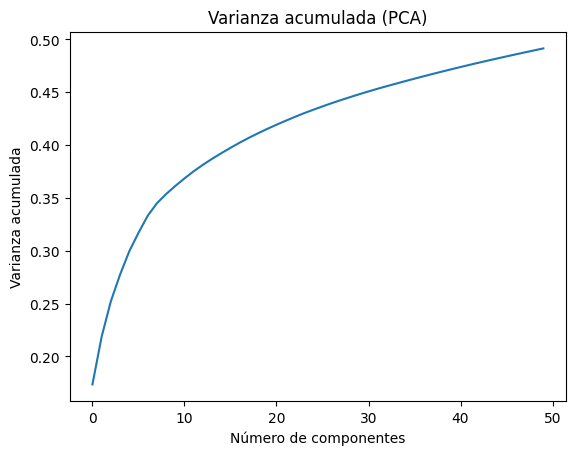

In [40]:
plt.figure()
plt.plot(var_ratio)
plt.title("Varianza explicada por cada componente PCA")
plt.xlabel("Componente")
plt.ylabel("Varianza explicada")
plt.show()

plt.figure()
plt.plot(var_acumulada)
plt.title("Varianza acumulada (PCA)")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.show()

Gráfico de varianza explicada:
- Comienza con valores altos y disminuye rápidamente
- Indica que los primeros componentes son los más importantes

Gráfico de varianza acumulada:
- Crece de forma progresiva (tipo logarítmica)
- Cada nuevo componente aporta menos información que el anterior

Esto confirma que existe una fuerte concentración de información en los primeros componentes.

In [41]:
loadings = adata.varm["PCs"]

for i in range(50):  # PC1 a PC50
    pc = loadings[:, i]
    
    # Top 5 genes con mayor peso
    top_idx = np.argsort(np.abs(pc))[::-1][:5]
    genes = adata.var_names[top_idx]
    
    print(f"PC{i+1} top genes:", list(genes))

PC1 top genes: ['FTL', 'HLA-DRA', 'FTH1', 'LYZ', 'CD74']
PC2 top genes: ['IGKC', 'ACTB', 'TMSB4X', 'JCHAIN', 'IGHA1']
PC3 top genes: ['NFKBIA', 'IL1B', 'APOC1', 'SAT1', 'CXCL8']
PC4 top genes: ['IGKC', 'CD74', 'CXCR4', 'IGHA1', 'RGS1']
PC5 top genes: ['IGKC', 'IGHA1', 'HLA-DRA', 'CD74', 'CCL4']
PC6 top genes: ['CCL4', 'NKG7', 'GNLY', 'GZMB', 'CCL5']
PC7 top genes: ['MT-CO3', 'MT-CO1', 'MT-CO2', 'MT-ND4', 'MT-ND2']
PC8 top genes: ['RGS1', 'S100A4', 'APOE', 'NFKBIA', 'CCL4']
PC9 top genes: ['TPSAB1', 'TPSB2', 'APOE', 'BTG1', 'CXCR4']
PC10 top genes: ['RPS27', 'CD69', 'FABP4', 'FOS', 'FTH1']
PC11 top genes: ['RPS27', 'CCL4', 'FTL', 'TMSB10', 'LYZ']
PC12 top genes: ['FOS', 'JUN', 'HSPA1A', 'HSPA1B', 'DNAJB1']
PC13 top genes: ['IGKC', 'IGLC2', 'IGLC3', 'IGHA1', 'JCHAIN']
PC14 top genes: ['IGHA1', 'IGHG1', 'IGHG3', 'IGLC3', 'IGLC2']
PC15 top genes: ['MT2A', 'MT1X', 'RGS1', 'MT1E', 'LYZ']
PC16 top genes: ['CCL4', 'MT2A', 'FOS', 'LGALS1', 'GNLY']
PC17 top genes: ['RGS1', 'MT2A', 'JUN', 'IGHG3'

Se analizaron los 50 componentes principales obtenidos a partir de los 2000 genes originales. Para cada componente, se identificaron los 5 genes con mayor contribución (mayor peso absoluto).

- PC1 (FTL, HLA-DRA, FTH1, LYZ, CD74): 
  Está asociado a genes relacionados con respuesta inmune e inflamación, lo que sugiere que este componente captura diferencias importantes entre tipos celulares del sistema inmune.
- PC2 y PC4–PC5 (IGKC, IGHA1, JCHAIN, etc.): 
  Dominados por genes de inmunoglobulinas → asociados a células B y plasmáticas. 
- PC3 (NFKBIA, IL1B, CXCL8, etc.): 
  Relacionado con procesos inflamatorios → captura estados de activación celular.
- PC6 (NKG7, GNLY, GZMB, CCL5): 
  Asociado a células citotóxicas (NK y T citotóxicas).  
- PC7 (genes mitocondriales: MT-CO1, MT-CO2, etc.):  
  Representa actividad metabólica o calidad celular.  
- PC12 (FOS, JUN, HSPA1A): 
  Genes de respuesta al estrés → indican activación celular o condiciones experimentales.

### Conclusión del PCA

- El PCA logra capturar patrones biológicamente relevantes
- Diferencia claramente:
  - Tipos celulares (B, NK, monocitos, etc.)
  - Estados celulares (activación, estrés, metabolismo)
- Los primeros componentes contienen la mayor información útil


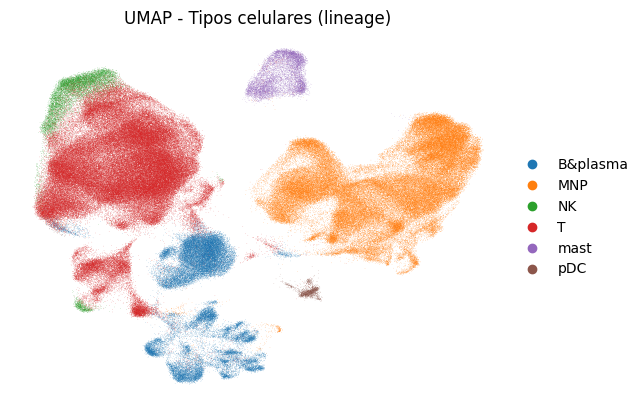

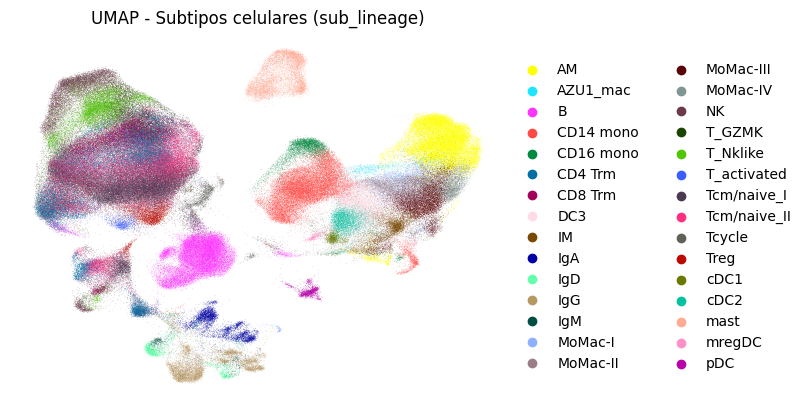

In [42]:
import scanpy as sc
sc.pl.umap(
    adata,
    color="lineage",
    title="UMAP - Tipos celulares (lineage)",
    frameon=False
)

sc.pl.umap(
    adata,
    color="sub_lineage",
    title="UMAP - Subtipos celulares (sub_lineage)",
    frameon=False
)

## Visualización UMAP e interpretación biológica

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad que proyecta datos de alta dimensión (expresión de 2000 genes) en un espacio de 2 dimensiones.

Su objetivo es preservar la estructura de los datos, especialmente en las relaciones locales (células similares quedan cerca) y la separación entre grupos distintos

- Cada punto representa una célula  
- La posición refleja similitud en su perfil de expresión génica  

### UMAP por tipo celular (`lineage`)
- Se observan clusters bien definidos, donde cada tipo celular ocupa una región específica del espacio.
- Las células del tipo T son claramente predominantes y forman un grupo amplio, consistente con el desbalance observado en el dataset.
- Los MNP (monocitos/macrófagos) se ubican hacia la zona centro-derecha, formando un grupo diferenciado.
- Las células NK aparecen agrupadas en la parte superior izquierda, separadas del resto.
- Las células B&plasma se concentran en la parte inferior izquierda, formando un cluster bien delimitado.
- Las células mast se agrupan en la zona central superior.
- Las células pDC aparecen como un grupo pequeño cerca del centro, lo que refleja su baja frecuencia.


Las células cercanas entre sí significan perfiles génicos similares, por lo tanto, misma función biológica.

### UMAP por subtipos celulares (`sub_lineage`)
- Se identifican zonas donde los subtipos están bien definidos, pero también regiones con mezcla de múltiples subtipos.
- En la zona superior izquierda se observa una superposición de varios subtipos, lo que sugiere similitud entre ellos.
- En la zona derecha también se evidencian regiones con mezcla, indicando que algunos subtipos comparten características moleculares.


El UMAP confirma que los datos tienen una estructura biológica bien definida:
- Los tipos celulares (`lineage`) se separan claramente, lo que respalda la viabilidad de un modelo de clasificación
- Los subtipos (`sub_lineage`) muestran mayor complejidad, con zonas de transición y similitud
- La posición de los puntos refleja relaciones biológicas reales entre células


In [43]:
riesgos = [
    ('Desbalance de clases',
     'Clases minoritarias (pDC, mast) vs. mayoritarias (T, MNP). '
     'Riesgo: el modelo puede ignorar clases minoritarias. '
     "Mitigación: usar class_weight='balanced', SMOTE, o métricas macro."),
    ('Alta sparsity (~91.8%)',
     'La mayoría de valores en la matriz de expresión son cero (dropouts). '
     'Riesgo: modelos sensibles a escala pueden verse afectados. '
     'Mitigación: usar PCA (ya aplicado).'),
    ('Fuente del dataset no publicada',
     'El dataset fue proporcionado por un contacto académico de la UTEM. '
     'No tiene DOI ni URL pública. '
     'Riesgo: no se puede reproducir la generación del archivo externamente. '
     'Mitigación: el archivo .h5ad contiene el preprocesamiento documentado internamente.'),
    ('PCA captura solo ~49% de varianza',
     'Con 50 componentes se retiene ~mitad de la varianza original. '
     'Riesgo: pérdida de información biológica. '
     'Mitigación: evaluar si aumentar componentes mejora el modelo.'),
    ('Sesgo de batch',
     'El dataset proviene de 91 muestras (sample_ID). '
     'Riesgo: efectos de batch pueden introducir variabilidad técnica. '
     'Mitigación: HVG seleccionados por batch (highly_variable_nbatches).'),
]

print('RIESGOS Y LIMITACIONES DEL DATASET')
print('=' * 60)
for i, (riesgo, descripcion) in enumerate(riesgos, 1):
    print(f'\n{i}. {riesgo}')
    print(f'   {descripcion}')
print('\n' + '=' * 60)

RIESGOS Y LIMITACIONES DEL DATASET

1. Desbalance de clases
   Clases minoritarias (pDC, mast) vs. mayoritarias (T, MNP). Riesgo: el modelo puede ignorar clases minoritarias. Mitigación: usar class_weight='balanced', SMOTE, o métricas macro.

2. Alta sparsity (~91.8%)
   La mayoría de valores en la matriz de expresión son cero (dropouts). Riesgo: modelos sensibles a escala pueden verse afectados. Mitigación: usar PCA (ya aplicado).

3. Fuente del dataset no publicada
   El dataset fue proporcionado por un contacto académico de la UTEM. No tiene DOI ni URL pública. Riesgo: no se puede reproducir la generación del archivo externamente. Mitigación: el archivo .h5ad contiene el preprocesamiento documentado internamente.

4. PCA captura solo ~49% de varianza
   Con 50 componentes se retiene ~mitad de la varianza original. Riesgo: pérdida de información biológica. Mitigación: evaluar si aumentar componentes mejora el modelo.

5. Sesgo de batch
   El dataset proviene de 91 muestras (sample_ID

In [6]:
from pathlib import Path

file_path = Path("..") / "data" / "raw" / "adata_final.h5ad"
adata_10 = adata[:10, :]
adata_10.write(Path("..") / "data" / "raw" / "adata_final_10.h5ad")

In [9]:
import numpy as np
from pathlib import Path

output_path = Path("..") / "data" / "processed"

# Cargar datos
X_train = np.load(output_path / "X_train.npy")
X_test  = np.load(output_path / "X_test.npy")
y_train = np.load(output_path / "y_train.npy")
y_test  = np.load(output_path / "y_test.npy")

# Reducir a 10
X_train_10 = X_train[:10]
y_train_10 = y_train[:10]

X_test_10  = X_test[:10]
y_test_10  = y_test[:10]

# Guardar NUEVOS archivos
np.save(output_path / "X_train_10.npy", X_train_10)
np.save(output_path / "X_test_10.npy", X_test_10)
np.save(output_path / "y_train_10.npy", y_train_10)
np.save(output_path / "y_test_10.npy", y_test_10)